In [4]:
import pandas as pd
import numpy as np
import wfdb
import matplotlib.pyplot as plt
import os
import cv2

# Add the correct paths to our modules
import sys
sys.path.append('../../src')
sys.path.append('../src') # For the synthesis utils

import config
from synthesis_utils import plot_ecg_on_paper, apply_paper_augmentations, apply_environment_augmentations

# --- Load the metadata ---
df_meta = pd.read_csv(os.path.join(config.DATA_PATH, config.METADATA_FILE), index_col='ecg_id')

print("Setup complete. Metadata loaded.")

Setup complete. Metadata loaded.


In [5]:
# Let's find a sample ECG to plot
sample_ecg_id = df_meta.index[10] # Using a different sample
filename = os.path.join(config.DATA_PATH, df_meta.loc[sample_ecg_id, 'filename_hr'])

# Load the high-resolution signal data
signal_data, signal_metadata = wfdb.rdsamp(filename)
leads = signal_metadata['sig_name']

print(f"Loaded signal for ecg_id: {sample_ecg_id}")

Loaded signal for ecg_id: 11


Displaying the ECG image with 'Paper' augmentations:


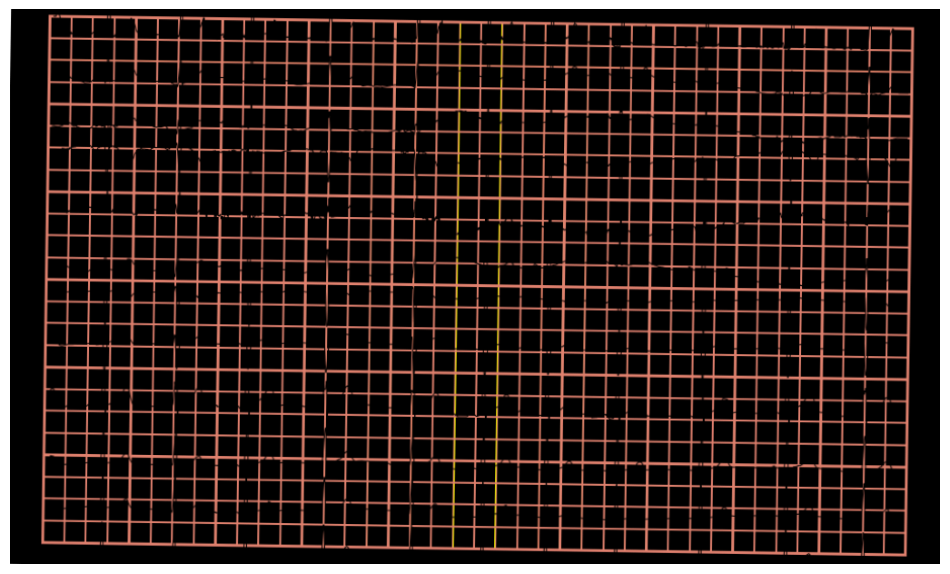

In [6]:
# Define the path to our paper background
paper_path = str(config.PROJECT_ROOT / 'data_synthesis' / 'background_images' / 'ecg_paper.png')

# 1. Create the base plot on real ECG paper
base_ecg_image = plot_ecg_on_paper(signal_data, leads, paper_path)

# 2. Apply paper-like augmentations (rotation, perspective)
realistic_ecg_image = apply_paper_augmentations(base_ecg_image)

# --- Display the intermediate result ---
print("Displaying the ECG image with 'Paper' augmentations:")
plt.figure(figsize=(12, 8))
plt.imshow(realistic_ecg_image)
plt.axis('off')
plt.show()

Displaying the final ECG image with 'Environment' augmentations:


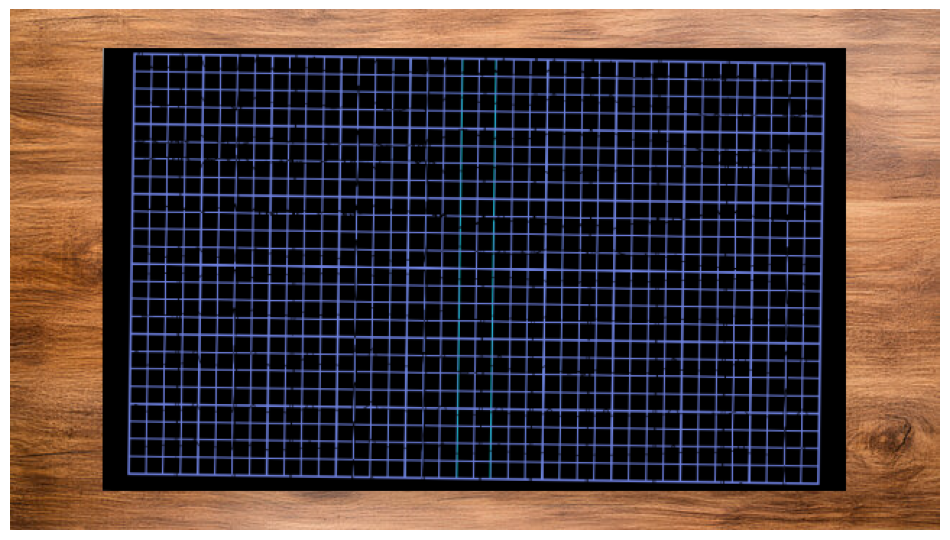

In [7]:
# Define the path to our environment background
background_path = str(config.PROJECT_ROOT / 'data_synthesis' / 'background_images' / 'desk.jpg')

# 3. Apply environment augmentations (background, shadow)
final_image = apply_environment_augmentations(realistic_ecg_image, background_path)

# --- Display the final, hyper-realistic image ---
print("Displaying the final ECG image with 'Environment' augmentations:")
plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(final_image, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()